### Step 1: Setup Colab Environment
Run this cell to install necessary libraries.

In [ ]:
!pip install transformers missingno

### Step 2: Create a Dataset with Missing Values
Let's prepare a simple text-based dataset to illustrate missing data.

In [ ]:
import pandas as pd
import numpy as np

# Example dataset with missing textual data
data = {
    'Review': ['This place is wonderful!', np.nan, 'I feel', 'Service was', np.nan],
    'Sentiment': ['positive', 'neutral', np.nan, 'negative', 'neutral']
}

df = pd.DataFrame(data)
display(df)

,Review,Sentiment
0,This place is wonderful!,positive
1,NaN,neutral
2,I feel,NaN
3,Service was,negative
4,NaN,neutral


### Step 3: Visualizing Missing Data
Use missingno to visualize missingness clearly.

<Axes: >

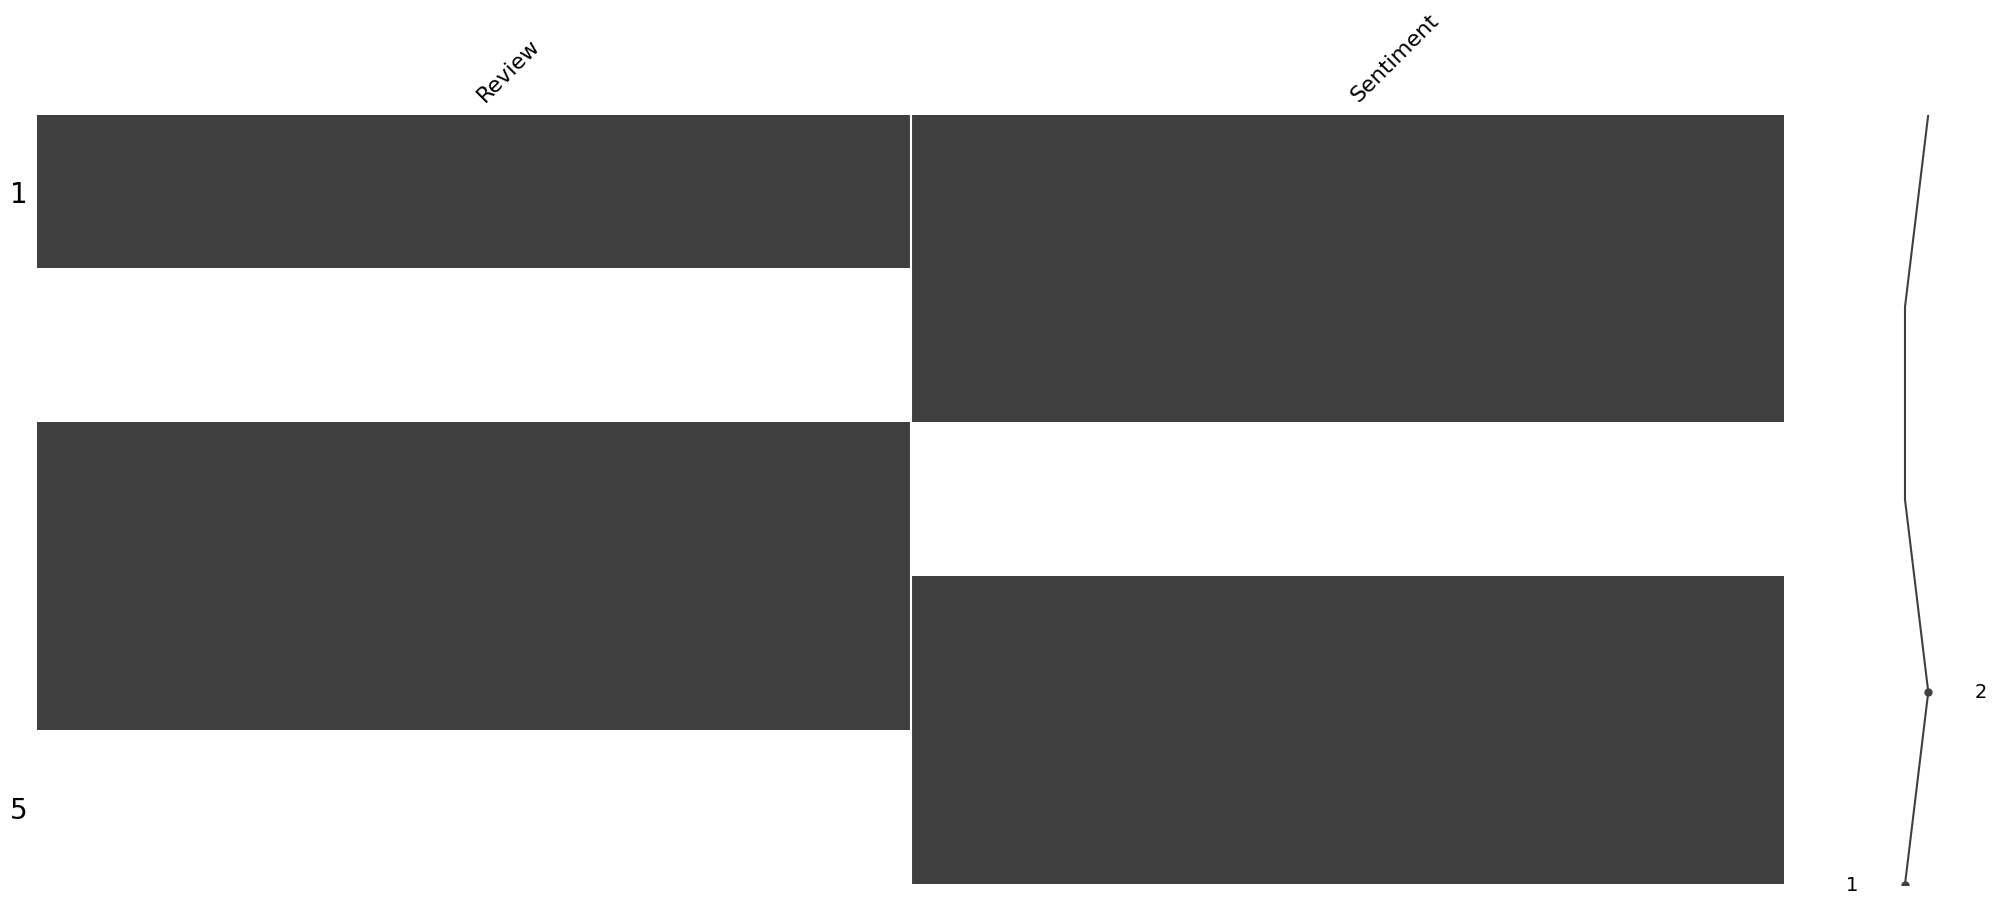

In [ ]:
import missingno as msno
msno.matrix(df)

### Step 4: Load a Small Language Model (SLM)
Load a lightweight language model suitable for quick inference on Colab.

In [ ]:
from transformers import pipeline

# Load a small language model (BERT-tiny)
fill_mask = pipeline('fill-mask', model='prajjwal1/bert-tiny')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/285 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/17.8M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/44 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie bert.embeddings.word_embeddings.weight to cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie cls.predictions.bias to cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BertForMaskedLM LOAD REPORT from: prajjwal1/bert-tiny
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 
cls.seq_relationship.weight  | UNEXPECTED |  | 
cls.seq_relationship.bias    | UNEXPECTED |  | 
bert.pooler.dense.weight     | UNEXPECTED |  | 
bert.pooler.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when 

model.safetensors:   0%|          | 0.00/17.7M [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

### Step 5: Demonstrate Simple Masked Prediction
See how the model fills in masked words:

In [ ]:
text = "The service here is [MASK]."
predictions = fill_mask(text)
display(predictions)

[{'score': 0.0715600848197937,
  'token': 2182,
  'token_str': 'here',
  'sequence': 'service here is here.'},
 {'score': 0.048838358372449875,
  'token': 2045,
  'token_str': 'there',
  'sequence': 'service here is there.'},
 {'score': 0.03677002713084221,
  'token': 2651,
  'token_str': 'today',
  'sequence': 'service here is today.'},
 {'score': 0.021330172196030617,
  'token': 2085,
  'token_str': 'now',
  'sequence': 'service here is now.'},
 {'score': 0.015669681131839752,
  'token': 2188,
  'token_str': 'home',
  'sequence': 'service here is home.'}]

### Step 6: Impute Missing Values using the SLM
Define a function to impute missing textual entries.

In [ ]:
def slm_impute(text, sentiment, slm_pipeline):
    if pd.isna(text):
        prompt = f"The sentiment of this review is {sentiment}, it is [MASK]."
        prediction = slm_pipeline(prompt)[0]['token_str']
        return prediction
    return text

# Apply imputation to Review
df['Review'] = df.apply(lambda row: slm_impute(row['Review'], row['Sentiment'], fill_mask), axis=1)

# Apply imputation to Sentiment
df['Sentiment'] = df.apply(lambda row: slm_impute(row['Sentiment'], row['Review'], fill_mask), axis=1)

display(df)

,Review,Sentiment
0,This place is wonderful!,positive
1,unclear,neutral
2,I feel,true
3,Service was,negative
4,unclear,neutral
